In [2]:
import pandas as pd
import numpy as np
import glob, os

merged = pd.read_csv(r"c:\Users\niran\OneDrive\Desktop\SitSense\data\merged\posture_sessions_merged.csv")

# Convert timestamps again just in case
merged["timestamp"] = pd.to_datetime(merged["timestamp"], errors="coerce")
merged["started_at"] = pd.to_datetime(merged["started_at"], errors="coerce")
merged["ended_at"] = pd.to_datetime(merged["ended_at"], errors="coerce")
merged["updated_at"] = pd.to_datetime(merged["updated_at"], errors="coerce")
merged["created_at"] = pd.to_datetime(merged["created_at"], errors="coerce")


In [3]:
merged.info()
merged.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   id_posture       7000 non-null   object             
 1   user_id_posture  7000 non-null   object             
 2   session_id       7000 non-null   object             
 3   timestamp        7000 non-null   datetime64[ns, UTC]
 4   metrics          7000 non-null   object             
 5   posture          7000 non-null   object             
 6   confidence       7000 non-null   float64            
 7   id_session       5852 non-null   object             
 8   user_id_session  5852 non-null   object             
 9   started_at       5852 non-null   datetime64[ns, UTC]
 10  ended_at         5852 non-null   datetime64[ns, UTC]
 11  status           5852 non-null   object             
 12  created_at       5852 non-null   datetime64[ns]     
 13  updated_at       5

,id_posture,user_id_posture,session_id,timestamp,metrics,posture,confidence,id_session,user_id_session,started_at,ended_at,status,created_at,updated_at,_merge
0,2cdc08d3-f80d-49a9-84e6-9dca27d22ba6,1ac653f4-5275-4e21-814d-56992851e16a,296056ea-9e62-4852-875a-8269dbea4c75,2025-10-06 08:22:32.903048+00:00,"{""cva_angle"": 1.9842126808714795, ""head_tilt"":...",good,1.00,296056ea-9e62-4852-875a-8269dbea4c75,1ac653f4-5275-4e21-814d-56992851e16a,2025-10-06 08:19:45.155000+00:00,2025-10-06 08:24:36.030000+00:00,ended,2025-10-06 08:19:45.154915,2025-10-06 08:24:36.030,both
1,4bc283aa-000f-4ba6-a93d-f23f4cb028a7,1ac653f4-5275-4e21-814d-56992851e16a,296056ea-9e62-4852-875a-8269dbea4c75,2025-10-06 08:22:27.862245+00:00,"{""cva_angle"": -6.738489703970799, ""head_tilt"":...",fair,0.75,296056ea-9e62-4852-875a-8269dbea4c75,1ac653f4-5275-4e21-814d-56992851e16a,2025-10-06 08:19:45.155000+00:00,2025-10-06 08:24:36.030000+00:00,ended,2025-10-06 08:19:45.154915,2025-10-06 08:24:36.030,both
2,bf5e458f-f5c5-4aaf-9f9f-7f5ced2ef2f3,1ac653f4-5275-4e21-814d-56992851e16a,296056ea-9e62-4852-875a-8269dbea4c75,2025-10-06 08:22:22.786503+00:00,"{""cva_angle"": 0.12198708517803425, ""head_tilt""...",good,1.00,296056ea-9e62-4852-875a-8269dbea4c75,1ac653f4-5275-4e21-814d-56992851e16a,2025-10-06 08:19:45.155000+00:00,2025-10-06 08:24:36.030000+00:00,ended,2025-10-06 08:19:45.154915,2025-10-06 08:24:36.030,both
3,7d27716e-fcf1-40d4-b3b5-659c9f2944cf,1ac653f4-5275-4e21-814d-56992851e16a,296056ea-9e62-4852-875a-8269dbea4c75,2025-10-06 08:22:17.814075+00:00,"{""cva_angle"": 1.2171196604729175, ""head_tilt"":...",good,1.00,296056ea-9e62-4852-875a-8269dbea4c75,1ac653f4-5275-4e21-814d-56992851e16a,2025-10-06 08:19:45.155000+00:00,2025-10-06 08:24:36.030000+00:00,ended,2025-10-06 08:19:45.154915,2025-10-06 08:24:36.030,both
4,23342e31-0dbf-46f9-a94b-b7ba5fcb3806,1ac653f4-5275-4e21-814d-56992851e16a,296056ea-9e62-4852-875a-8269dbea4c75,2025-10-06 08:22:12.681625+00:00,"{""cva_angle"": 2.1016236763927907, ""head_tilt"":...",good,1.00,296056ea-9e62-4852-875a-8269dbea4c75,1ac653f4-5275-4e21-814d-56992851e16a,2025-10-06 08:19:45.155000+00:00,2025-10-06 08:24:36.030000+00:00,ended,2025-10-06 08:19:45.154915,2025-10-06 08:24:36.030,both


In [4]:
merged.describe(include='all')

,id_posture,user_id_posture,session_id,timestamp,metrics,posture,confidence,id_session,user_id_session,started_at,ended_at,status,created_at,updated_at,_merge
count,7000,7000,7000,7000,7000,7000,7000.000000,5852,5852,5852,5852,5852,5852,5852,7000
unique,7000,23,75,NaN,7000,3,NaN,50,19,NaN,NaN,1,NaN,NaN,2
top,2cdc08d3-f80d-49a9-84e6-9dca27d22ba6,1ac653f4-5275-4e21-814d-56992851e16a,4f0d2c3a-4d11-477a-b61d-21503d2317e7,NaN,"{""cva_angle"": 1.9842126808714795, ""head_tilt"":...",good,NaN,4f0d2c3a-4d11-477a-b61d-21503d2317e7,1ac653f4-5275-4e21-814d-56992851e16a,NaN,NaN,ended,NaN,NaN,both
freq,1,2469,1003,NaN,1,4947,NaN,1003,2283,NaN,NaN,5852,NaN,NaN,5852
mean,NaN,NaN,NaN,2025-09-26 15:06:15.653135360+00:00,NaN,NaN,0.905107,NaN,NaN,2025-09-26 15:17:50.011063040+00:00,2025-09-26 16:32:00.205713664+00:00,NaN,2025-09-26 15:17:50.020962816,2025-09-26 16:32:00.205714688,NaN
min,NaN,NaN,NaN,2025-09-12 17:33:53.238168+00:00,NaN,NaN,0.500000,NaN,NaN,2025-09-12 16:48:56.772000+00:00,2025-09-12 17:48:53.146000+00:00,NaN,2025-09-12 16:48:56.877669,2025-09-12 17:48:53.146000,NaN
25%,NaN,NaN,NaN,2025-09-20 07:17:57.527537152+00:00,NaN,NaN,0.750000,NaN,NaN,2025-09-19 10:56:03.302000128+00:00,2025-09-19 11:19:04.376000+00:00,NaN,2025-09-19 10:56:03.304709120,2025-09-19 11:19:04.376000,NaN
50%,NaN,NaN,NaN,2025-09-28 16:31:49.480102144+00:00,NaN,NaN,1.000000,NaN,NaN,2025-09-28 15:24:48.776999936+00:00,2025-09-28 16:42:51.244000+00:00,NaN,2025-09-28 15:24:48.778200064,2025-09-28 16:42:51.244000,NaN
75%,NaN,NaN,NaN,2025-10-03 09:29:35.670239744+00:00,NaN,NaN,1.000000,NaN,NaN,2025-10-03 08:14:37.128999936+00:00,2025-10-03 09:38:40.448000+00:00,NaN,2025-10-03 08:14:37.131525120,2025-10-03 09:38:40.448000,NaN
max,NaN,NaN,NaN,2025-10-09 19:59:59.541209+00:00,NaN,NaN,1.000000,NaN,NaN,2025-10-09 19:57:25.416000+00:00,2025-10-09 20:00:04.108000+00:00,NaN,2025-10-09 19:57:25.420396,2025-10-09 20:00:04.108000,NaN


C:\Users\niran\AppData\Local\Temp\ipykernel_41948\3082056329.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\niran\AppData\Local\Temp\ipykernel_41948\3082056329.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in order], fontsize=12)


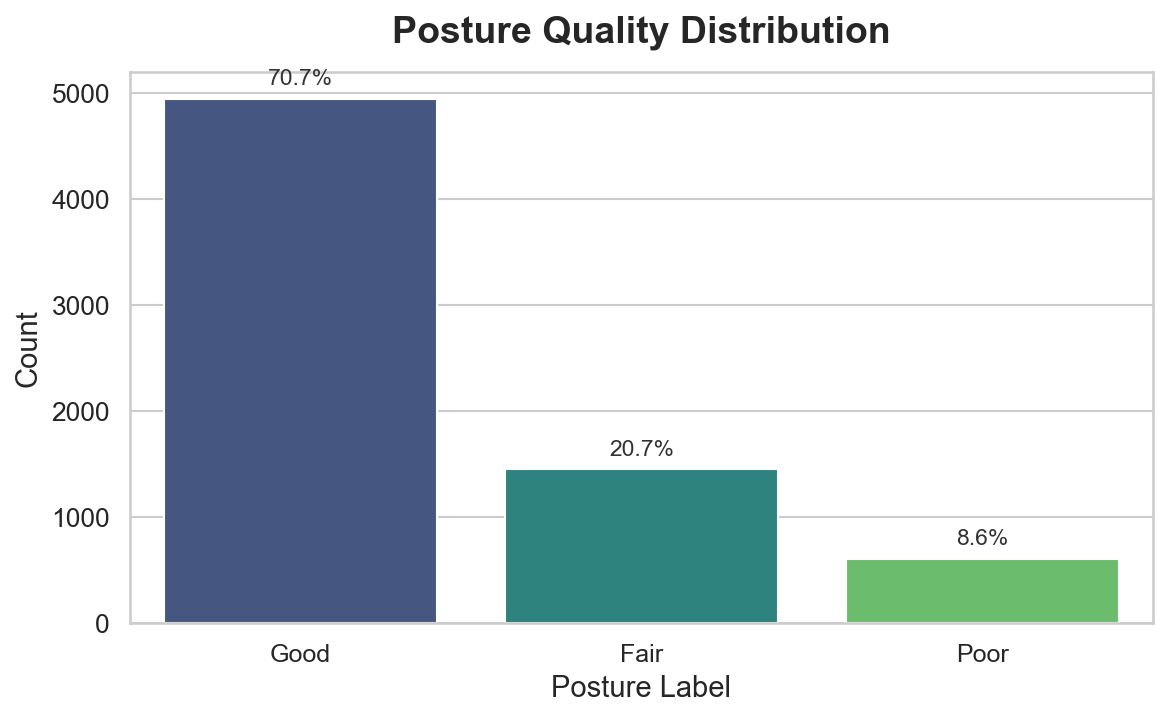

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1) Prepare data
# -----------------------------
counts = merged["posture"].value_counts()
order = counts.index
total = counts.sum()

# -----------------------------
# 2) Modern aesthetic
# -----------------------------
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.figure(figsize=(8,5), dpi=150)

# -----------------------------
# 3) Bar plot
# -----------------------------
palette = sns.color_palette("viridis", len(order))  # elegant/professional color scheme
ax = sns.countplot(
    x="posture", 
    data=merged,
    order=order,
    palette=palette
)

# -----------------------------
# 4) Annotate each bar with percentage
# -----------------------------
for p in ax.patches:
    height = p.get_height()
    pct = f"{(height / total) * 100:.1f}%"  
    x = p.get_x() + p.get_width() / 2
    ax.annotate(
        pct,
        (x, height),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 5),
        textcoords="offset points",
        color="#333"
    )

# -----------------------------
# 5) Titles & labels
# -----------------------------
ax.set_title("Posture Quality Distribution", fontsize=18, weight="bold", pad=15)
ax.set_xlabel("Posture Label", fontsize=14)
ax.set_ylabel("Count", fontsize=14)

# Make tick labels nicer
ax.set_xticklabels([label.capitalize() for label in order], fontsize=12)

# Tight layout (no clipping)
plt.tight_layout()

# -----------------------------
# 6) Save the figure for GitHub
# -----------------------------
plt.savefig("../plots/posture_distribution.png", dpi=200, bbox_inches="tight")

plt.show()


Valid sessions: 5831
Mean duration:  58.10 min
Median duration:75.61 min
99th pct cap:   84.70 min


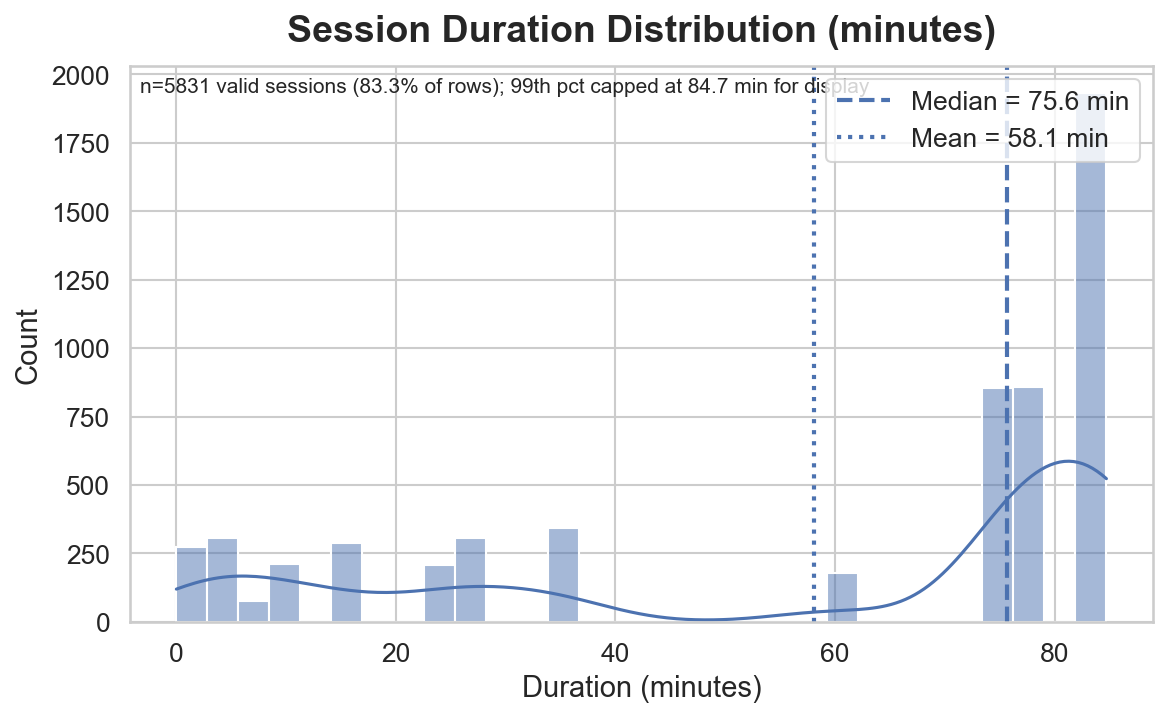

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1) Compute session duration (in minutes)
# -----------------------------
# Guard: ensure datetimes
for c in ["started_at", "ended_at"]:
    if merged[c].dtype != "datetime64[ns, UTC]" and not np.issubdtype(merged[c].dtype, np.datetime64):
        merged[c] = pd.to_datetime(merged[c], errors="coerce")

# Raw duration in minutes
merged["duration_minutes_raw"] = (merged["ended_at"] - merged["started_at"]).dt.total_seconds() / 60

# -----------------------------
# 2) Clean the duration column
# -----------------------------
# Drop impossible/invalid durations: NaN, negative, or absurdly long (e.g., > 3 hours = 180 min)
dur = merged["duration_minutes_raw"]
clean_mask = dur.notna() & (dur >= 0) & (dur <= 180)
merged["duration_minutes"] = dur.where(clean_mask, np.nan)

# (Optional) Winsorize mild outliers at the 99th percentile for nicer plots (keeps raw intact)
p99 = merged["duration_minutes"].quantile(0.99)
merged["duration_minutes_plot"] = merged["duration_minutes"].clip(upper=p99)

# -----------------------------
# 3) Quick stats (good to print in notebook and use in title/annotation)
# -----------------------------
n_valid = merged["duration_minutes"].notna().sum()
mean_dur = merged["duration_minutes"].mean()
median_dur = merged["duration_minutes"].median()

print(f"Valid sessions: {n_valid}")
print(f"Mean duration:  {mean_dur:.2f} min")
print(f"Median duration:{median_dur:.2f} min")
print(f"99th pct cap:   {p99:.2f} min")

# -----------------------------
# 4) Plot: Histogram + KDE, with median & mean markers and % annotation
# -----------------------------
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.figure(figsize=(8,5), dpi=150)

ax = sns.histplot(
    data=merged,
    x="duration_minutes_plot",
    bins=30,
    kde=True
)

# Median & mean vertical lines
ax.axvline(median_dur, linestyle="--", linewidth=2, label=f"Median = {median_dur:.1f} min")
ax.axvline(mean_dur,   linestyle=":",  linewidth=2, label=f"Mean = {mean_dur:.1f} min")

# Axis labels & title
ax.set_title("Session Duration Distribution (minutes)", fontsize=18, weight="bold", pad=12)
ax.set_xlabel("Duration (minutes)", fontsize=14)
ax.set_ylabel("Count", fontsize=14)

# Percent of rows included after cleaning (for transparency)
total_rows = len(merged)
pct_kept = (n_valid / total_rows) * 100 if total_rows else 0
subtitle = f"n={n_valid} valid sessions ({pct_kept:.1f}% of rows); 99th pct capped at {p99:.1f} min for display"
ax.text(0.01, 0.98, subtitle, transform=ax.transAxes, ha="left", va="top", fontsize=10)

# Legend & layout
ax.legend(loc="upper right")
plt.tight_layout()

# -----------------------------
# 5) Save figure for GitHub
# -----------------------------
plt.savefig(r"c:\Users\niran\OneDrive\Desktop\SitSense\plots\session_duration_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


Sample raw 'metrics' values:
['{"cva_angle": 1.9842126808714795, "head_tilt": 0, "neck_turn": 0.04723087678735283, "neck_angle": 2.3733739555569713, "trunk_angle": 0, "head_forward": 1.6369040348327992, "shoulder_slope": 2.7946839359858693}', '{"cva_angle": -6.738489703970799, "head_tilt": -5.07537392998584, "neck_turn": 11.634130817785831, "neck_angle": 5.675526918291553, "trunk_angle": 0, "head_forward": 3.0994343880177304, "shoulder_slope": 3.988675998406022}', '{"cva_angle": 0.12198708517803425, "head_tilt": 0, "neck_turn": 2.6773033398786197, "neck_angle": 3.521838908242044, "trunk_angle": 0, "head_forward": 1.6997997062122998, "shoulder_slope": 1.4689642918361103}', '{"cva_angle": 1.2171196604729175, "head_tilt": 0, "neck_turn": -1.8871424562720307, "neck_angle": 4.183486510588663, "trunk_angle": 0, "head_forward": 1.9661617463095968, "shoulder_slope": 1.5540361704160537}', '{"cva_angle": 2.1016236763927907, "head_tilt": 0, "neck_turn": -0.08649683322779822, "neck_angle": 0.44762

<Figure size 1500x900 with 0 Axes>

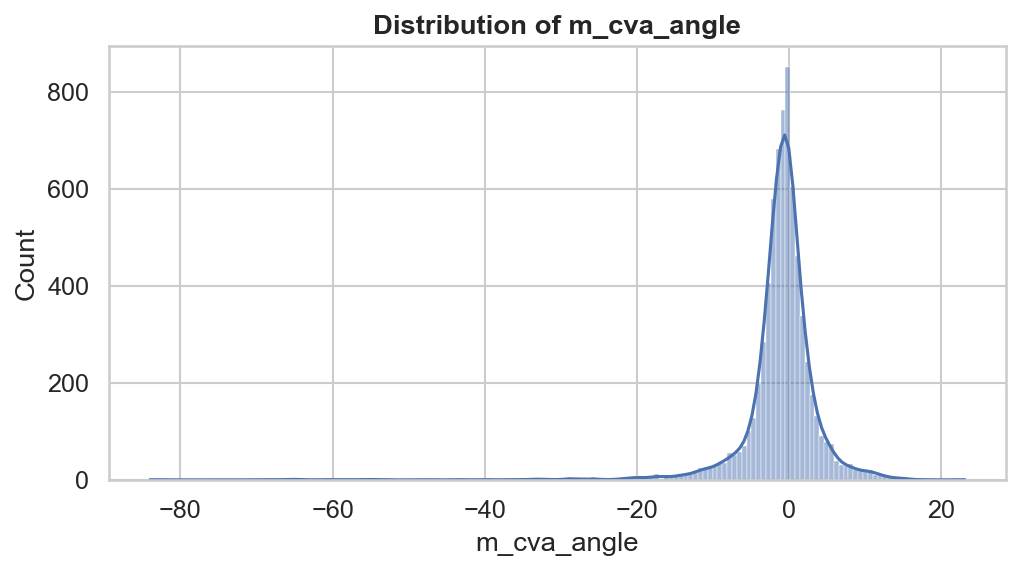

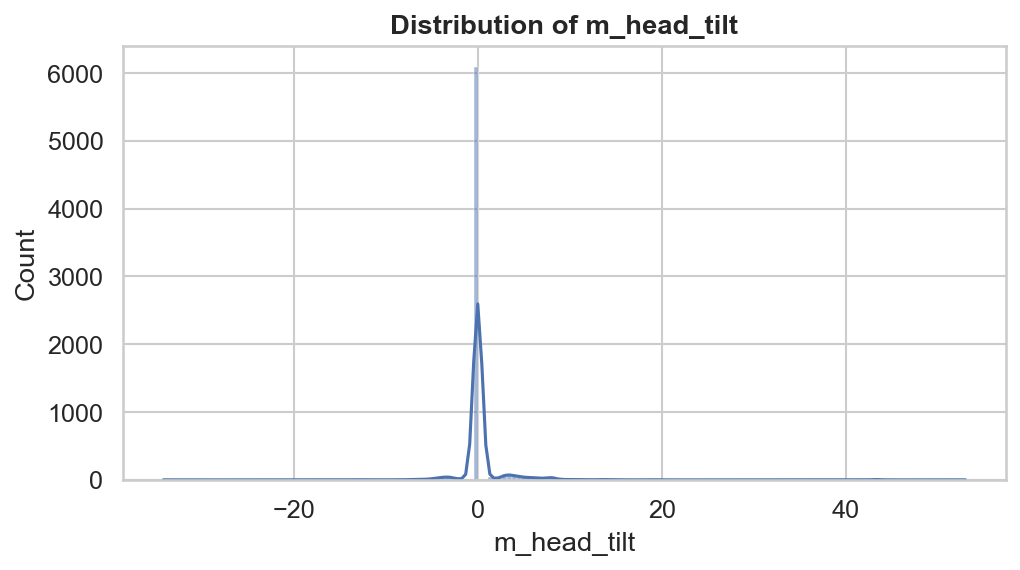

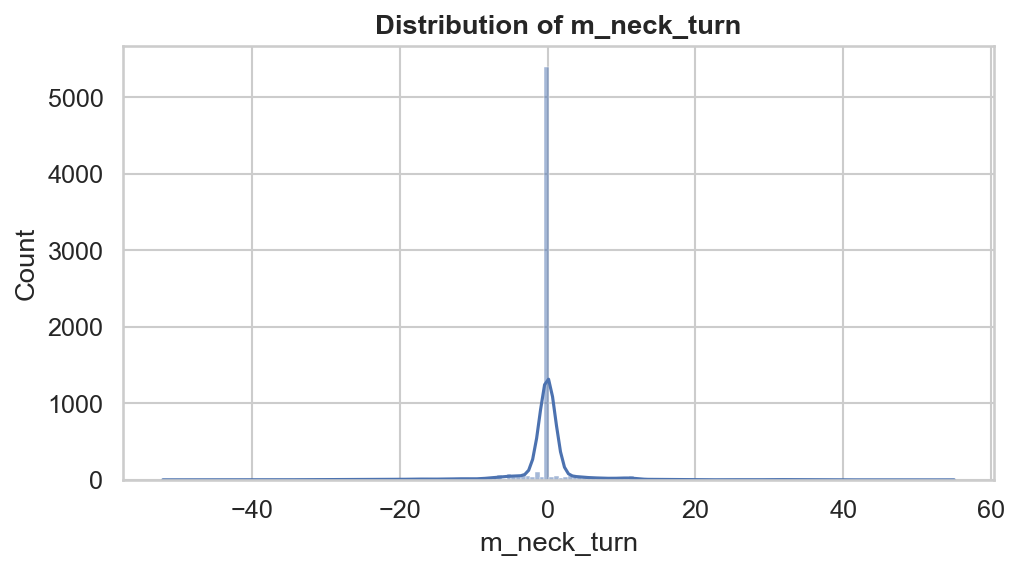

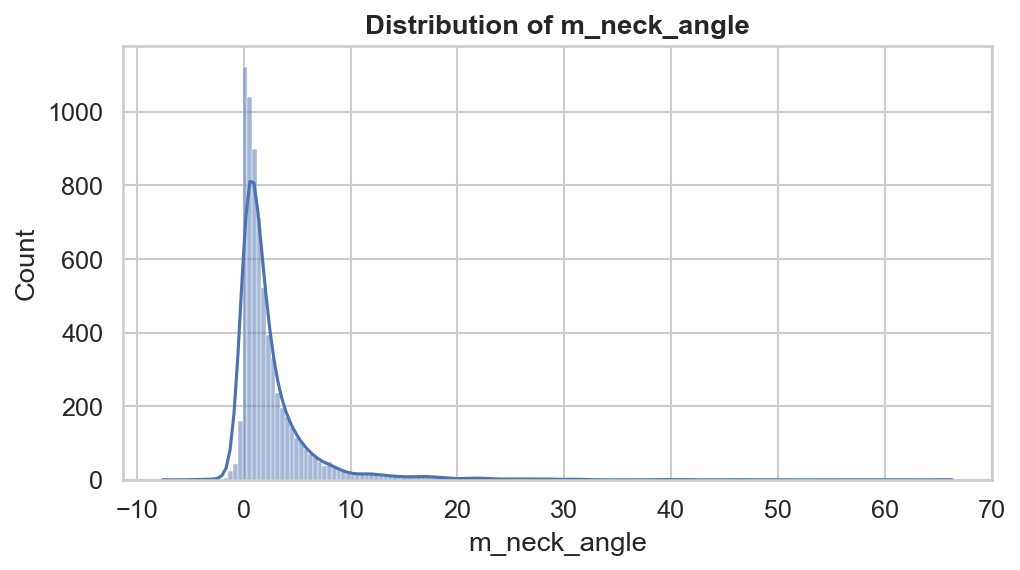

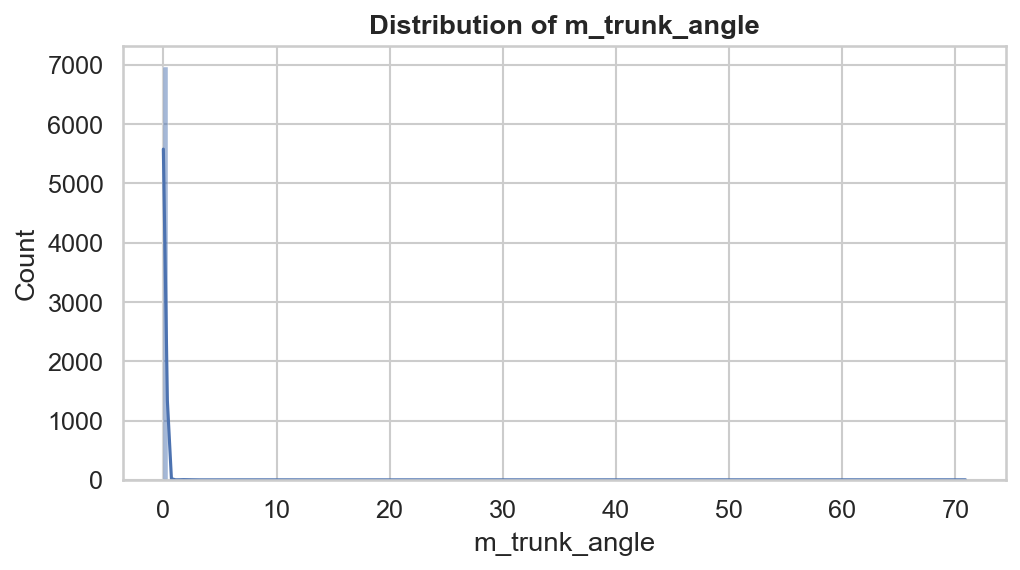

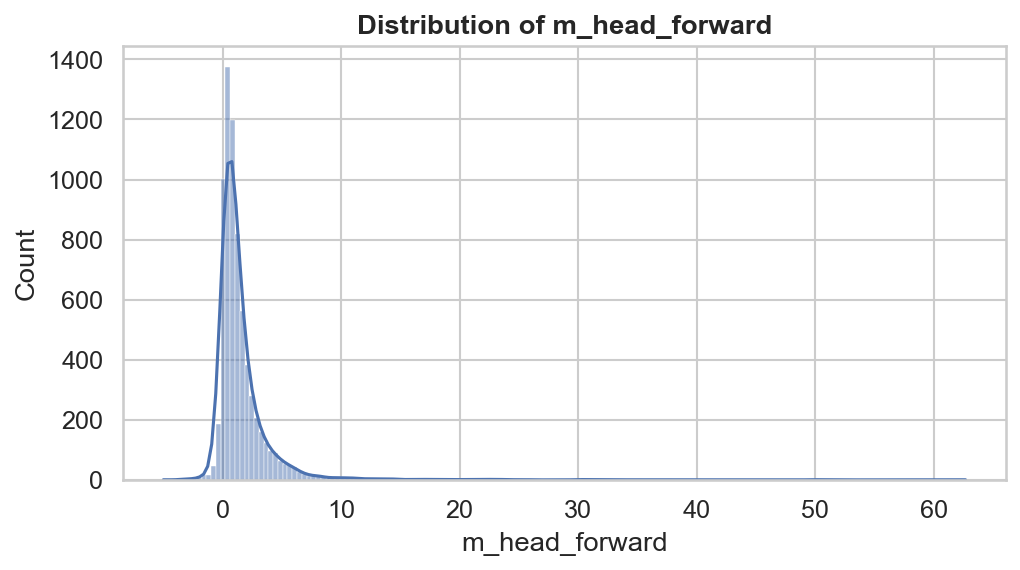

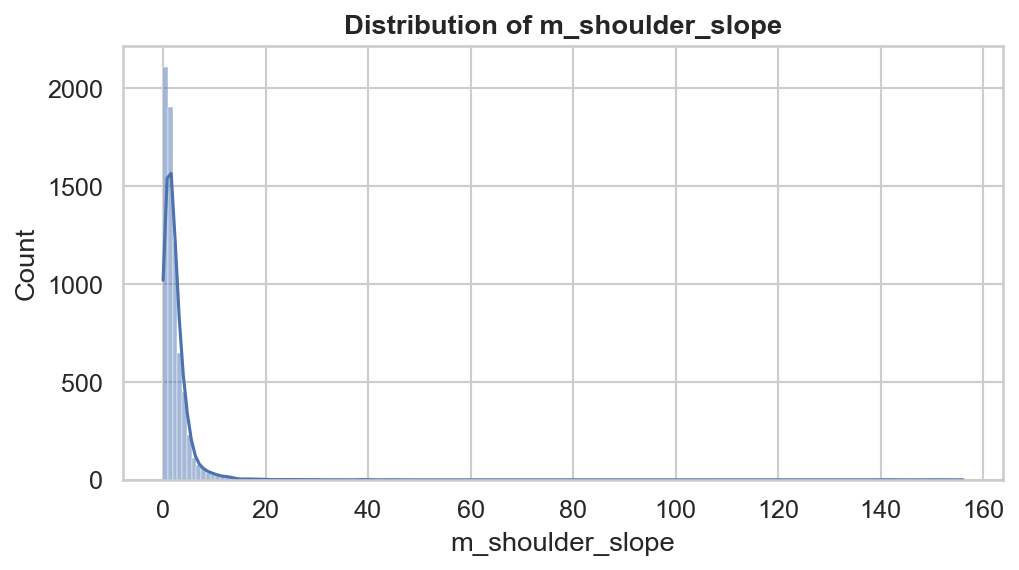

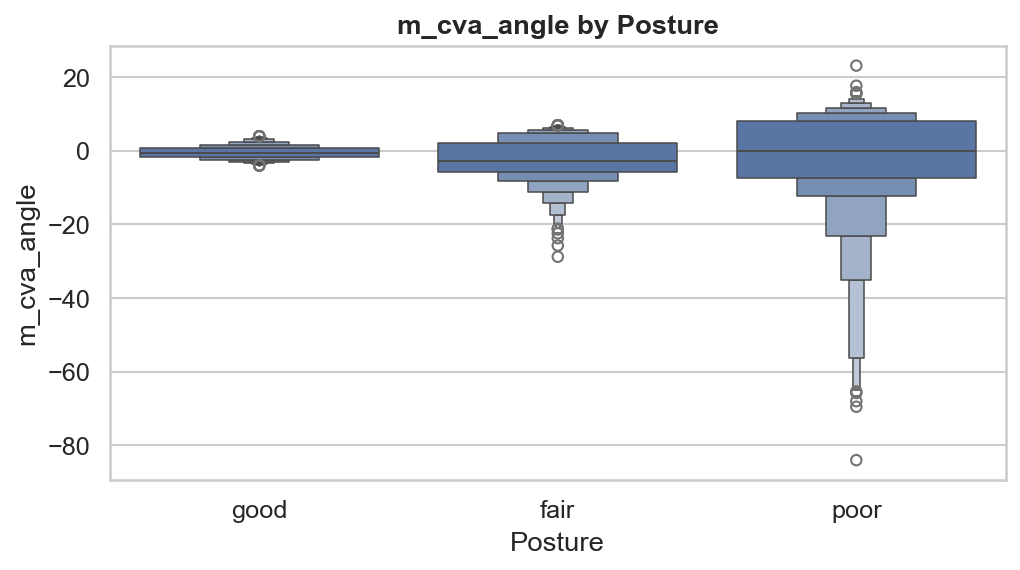

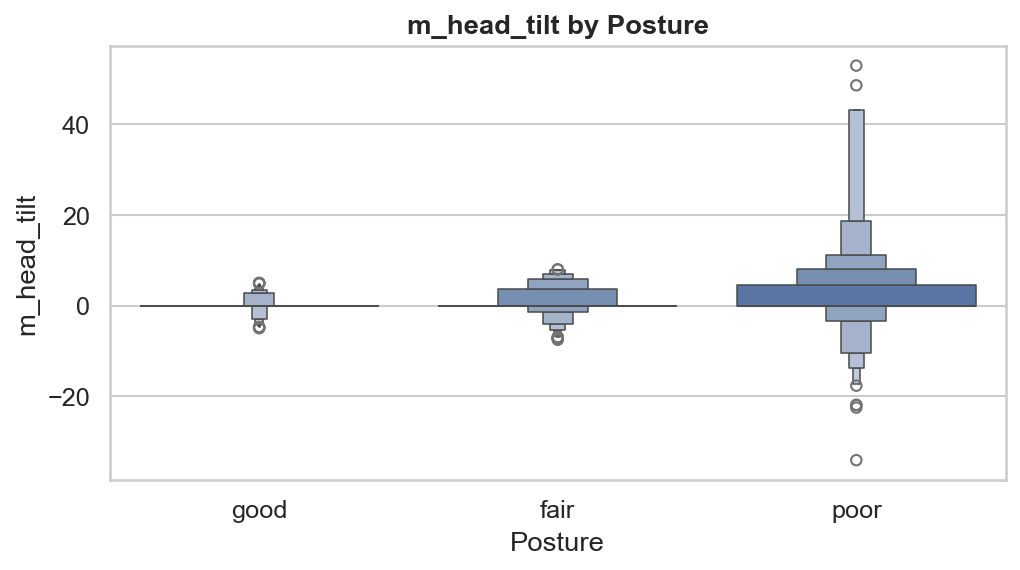

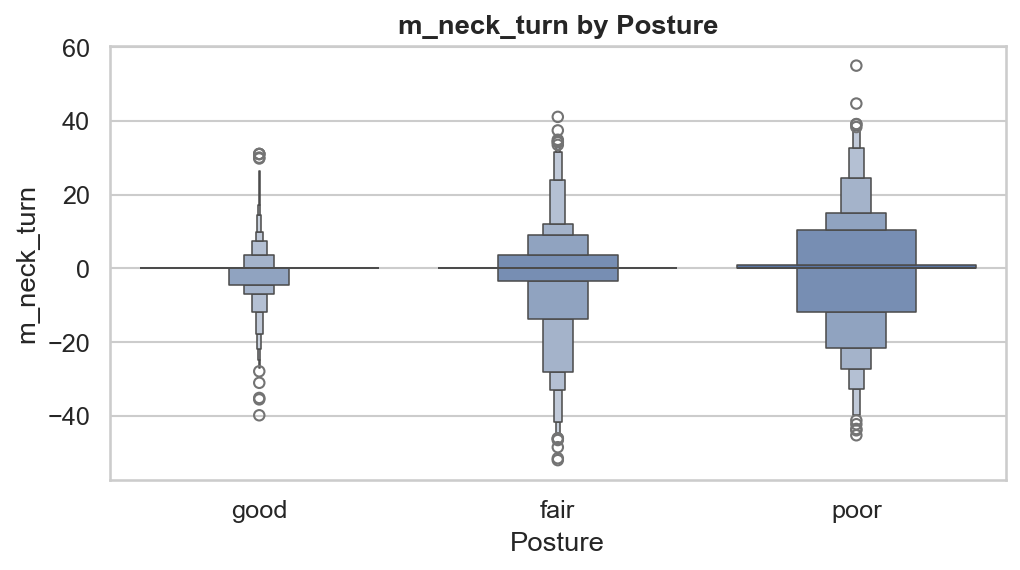

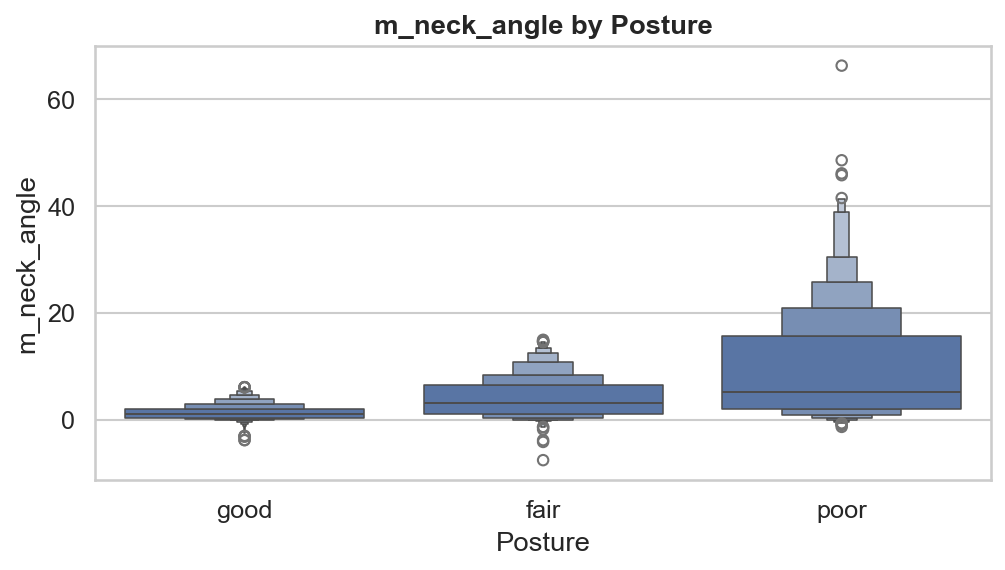

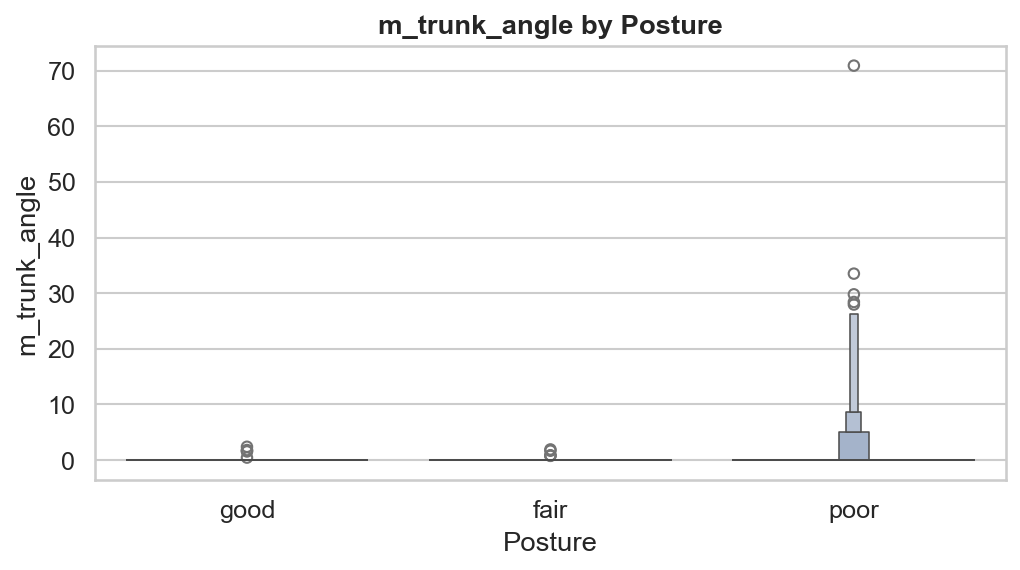

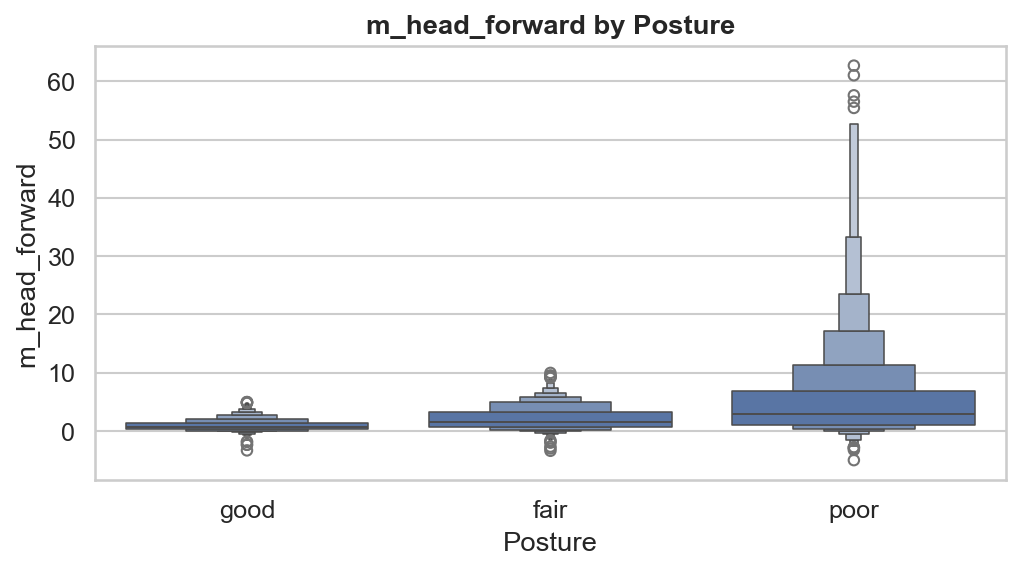

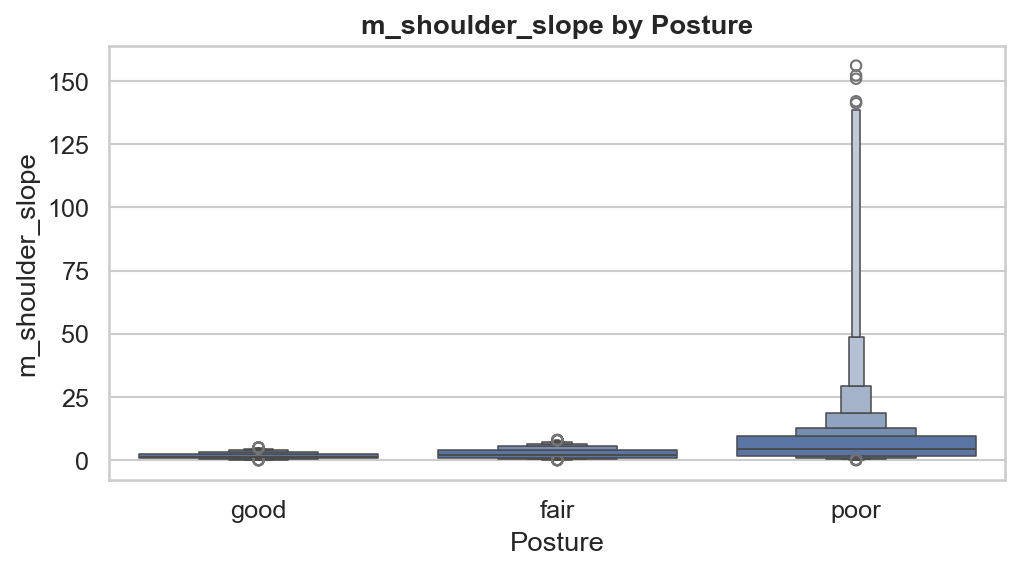

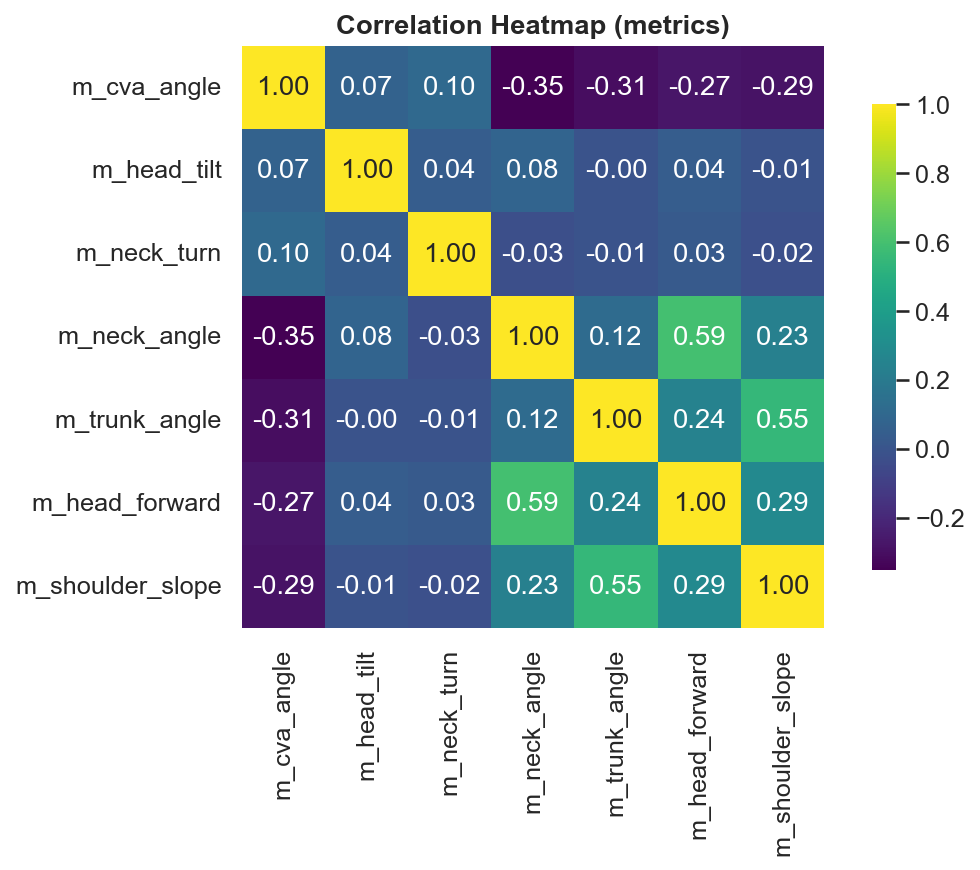

In [ ]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
#we set the themes of how we want are gird to look like and our font scales
sns.set_theme(style="whitegrid", font_scale=1.1)
#just making sure the plots folder is accessible, because thats where we are going to plot our graphs
os.makedirs("../plots", exist_ok=True)

# ---------------------------------------
# 1) Inspect a few raw 'metrics' values
# ---------------------------------------
print("Sample raw 'metrics' values:")
print(merged["metrics"].dropna().astype(str).head(5).tolist())#we drop null value metrics, convert the metrics type 
#to string and look at the first 5 values in a list from just to do a sanity-check

# ---------------------------------------
# 2) Safe JSON parser for mixed cases
#    - handles dicts, JSON strings, None/NaN, single quotes
# ---------------------------------------
def safe_parse_metrics(x):#this is a function about to be applied to each row

    if pd.isna(x):#if the row is NaN, the we return a blank dict to proceed safely
        return {}
    
    if isinstance(x, dict):
        return x#if its already a dict, proceed with the dict
    
    s = str(x).strip()#change whatever x is into a string and strip white spaces for efficiency

    if not s or s.lower() in {"none", "nan"}:
        return {}#if this string is none we proceed safely with empty dic
    
    # normalize single quotes to double quotes if needed
    if "'" in s and '"' not in s:
        s = s.replace("'", '"')
    try:
        return json.loads(s) #we parse with json package
    except Exception:
        # last resort: try to coerce key:value pairs very crudely
        try:
            # e.g. {cva_angle: 1.23, head_tilt: 0.5} -> {"cva_angle": 1.23, "head_tilt": 0.5}
            s2 = (
                s.replace("{", "")
                 .replace("}", "")
                 .replace(":", "=")
            )
            # turn "a=1, b=2" into dict
            pairs = [kv.strip() for kv in s2.split(",") if "=" in kv]
            d = {}
            for kv in pairs:
                k, v = [t.strip() for t in kv.split("=", 1)]
                k = k.strip('"').strip("'")
                # numeric if possible
                try:
                    v = float(v)
                except Exception:
                    v = v.strip('"').strip("'")
                d[k] = v
            return d
        except Exception:
            return {}

# ---------------------------------------
# 3) Parse the column into dictionaries
# ---------------------------------------
parsed = merged["metrics"].apply(safe_parse_metrics)#we use the function to do this for each row

# ---------------------------------------
# 4) Discover available metric keys
# ---------------------------------------
# Collect keys that occur frequently (avoid random junk)

#constructing a loop for each dictionary in the series of dictionary parsed and count each key 
# by adding value of key by 1 in key_counts dict for every time there is a key in the series
key_counts = {}
for d in parsed:
    for k in d.keys():
        key_counts[k] = key_counts.get(k, 0) + 1

print("Metric keys & counts (top 15):")
print(sorted(key_counts.items(), key=lambda x: x[1], reverse=True)[:15])
#series of keys and their counts are sorted based on descending order of count values


# Choose a shortlist to extract (adjust based on printout)
candidate_keys = [k for k, c in key_counts.items() if c >= max(5, 0.01*len(parsed))]  
#list comprehension where we take every k where c is more than 1 percent(big data) or 5(small data)
#done by looping through k,c in key_counts and checking c, if condition is True, k is added to candidate_keys
print("Selected keys to extract:", candidate_keys)

# ---------------------------------------
# 5) Expand the dictionaries into columns
# ---------------------------------------
metrics_df = pd.json_normalize(parsed)  # turns list of dicts into DataFrame
metrics_df = metrics_df.reindex(columns=candidate_keys)  # keep only selected keys(relevant ones)

# Coerce numeric where possible
for col in metrics_df.columns:
    metrics_df[col] = pd.to_numeric(metrics_df[col], errors="coerce")

# Prefix to avoid name collisions, then attach
metrics_df = metrics_df.add_prefix("m_")

#we merge the merged(sessions and posture analysis files combined) and the cleaned, parsed metrics data
merged_metrics = pd.concat([merged.reset_index(drop=True), metrics_df.reset_index(drop=True)], axis=1)

print("New metric columns added:", metrics_df.columns.tolist())

# ---------------------------------------
# 6) Quick stats & sanity checks
# ---------------------------------------
print(merged_metrics.filter(like="m_").describe().T)

# ---------------------------------------
# 7) Visualization A: Distributions of top metrics
# ---------------------------------------
num_cols = merged_metrics.filter(like="m_").columns  # picking numeric metrics for display
#we build a chart using plt
plt.figure(figsize=(10,6), dpi=150)
#for every col"this means every metric taken from num_cols" we proceed to build a histplot
for i, col in enumerate(num_cols, 1):
    plt.figure(figsize=(7,4), dpi=150)
    #from the data of merged metrics we analyze each column individually
    ax = sns.histplot(data=merged_metrics, x=col, kde=True)
    ax.set_title(f"Distribution of {col}", weight="bold")
    ax.set_xlabel(col)
    plt.tight_layout()
    #saves each metric
    plt.savefig(f"../plots/dist_{col}.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---------------------------------------
# 8) Visualization B: Metric vs Posture (categorical)
#    Boxen plots are great for distribution shape
# ---------------------------------------
for col in num_cols:
    #we repeat the same analysis but this time take a boxplot where x is the posture rating and analyze how the columns affect it
    # data is again taken from merged_matrix
    plt.figure(figsize=(7,4), dpi=150)
    ax = sns.boxenplot(data=merged_metrics, x="posture", y=col, order=merged["posture"].value_counts().index)
    ax.set_title(f"{col} by Posture", weight="bold")
    ax.set_xlabel("Posture")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.savefig(f"../plots/{col}_by_posture.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---------------------------------------
# 9) Visualization C: Correlation Heatmap of metrics
# ---------------------------------------
#this feels a little tricky
#we take num_cols again but this time we attempt to find any correlation between these metrics using a heatmap,"pearson" method
#very bold attempt to extract list of metric columns at once to correlate
corr = merged_metrics[num_cols].corr(method="pearson", min_periods=100)  # require 100 non-NaN pairs
#we build the heatmap
plt.figure(figsize=(8,6), dpi=150)
#colors are viridis and heatmap is is in squares, we round data values to the 2nd decimal point
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True, cbar_kws={"shrink": .8})
ax.set_title("Correlation Heatmap (metrics)", weight="bold")
plt.tight_layout()
plt.savefig("../plots/metrics_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


**Posture Analytics – EDA Insight Summary**

**1. Posture Label Distribution**

Figure: posture_distribution.png

Good posture dominates the dataset → 70.7% of all labeled frames.

Fair posture: 20.7%

Poor posture: 8.6%

Interpretation:
data is imbalanced, especially towards poor posture

**2. Session Duration Patterns**

Figure: session_duration_distribution.png

Valid sessions: 5 831 (≈83% of processed rows)

Median duration: 75.6 min

Mean duration: 58.1 min

99th percentile cutoff: 84.7 min (applied to prevent extreme skew)

Interpretation:
Users tend to sit continuously for long, continuous sessions.
Outliers are considered to be abnormally long sessions or short incomplete sessions

**3. Metric Distributions (Univariate Analysis)**

**3.1 m_cva_angle (Craniovertebral Angle)**

Figures: dist_m_cva_angle.png, m_cva_angle_by_posture.png

Distribution sharply centered around 0° to −5°, with long tail down to −85°.

Higher (positive) values = better posture.

Poor posture group shows dramatically lower CVA (−40° to −90°).

Good posture tightly clusters around 0° to 5°.

Interpretation:
CVA is the strongest single indicator separating posture quality.
Lower CVA = forward-head posture.

**3.2 m_head_forward**

Figures: dist_m_head_forward.png, m_head_forward_by_posture.png

Highly right-skewed.

Good posture: typically 0–3°

Fair posture: 2–6°

Poor posture: 8–30°, with some extreme outliers >50°.

Interpretation:
Head-forward displacement increases monotonically with posture quality deterioration.
This metric strongly differentiates fair & poor posture.

**3.3 m_head_tilt**

Figures: dist_m_head_tilt.png, m_head_tilt_by_posture.png

Tight cluster around 0°, small symmetric deviations.

Poor posture introduces occasional extreme values (±30–50°).

Interpretation:
Head tilt is not a main posture classifier for most users, except for extreme leaning or slouching.
Mostly noise except in poor posture outliers.

**3.4 m_neck_angle**

Figures: dist_m_neck_angle.png, m_neck_angle_by_posture.png

Good posture centered around 0–2°

Fair posture moves to 3–8°

Poor posture jumps to 10–40°, with occasional extreme outliers up to ~65°.

Interpretation:
Neck angle is a strong differentiator, indicating neck extension or flexion.
Good → Fair → Poor forms a clear, smooth gradient.

**3.5 m_neck_turn**

Figures: dist_m_neck_turn.png, m_neck_turn_by_posture.png

Highly centered around 0° for all groups.

Fair & poor posture show more extreme turning (±40–50°).

Distribution mostly noise for good posture.

Interpretation:
Neck turn is mostly symmetric noise, useful only for detecting rotational misalignment or looking sideways.

**3.6 m_shoulder_slope**

Figures: dist_m_shoulder_slope.png, m_shoulder_slope_by_posture.png

Good/Fair posture cluster tightly around 2–6°.

Poor posture shows massive spread: 8–40°, extremes up to 150°.

Interpretation:
Shoulder slope spikes in poor posture.
High variability suggests compensatory leaning or asymmetry.

**3.7 m_trunk_angle**

Figures: dist_m_trunk_angle.png, m_trunk_angle_by_posture.png

Flat near 0–1° for good/fair posture.

Poor posture exhibits strong right-tail (10°–70°).

Interpretation:
Trunk angle clearly marks slouching or forward trunk lean, highly informative for poor posture detection.

**4. Correlation Insights**

Figure: metrics_correlation_heatmap.png

Strong correlations:

m_head_forward ↔ m_neck_angle: 0.59

m_trunk_angle ↔ m_shoulder_slope: 0.55

m_trunk_angle ↔ m_head_forward: 0.24

Negative correlations:

m_cva_angle ↔ m_neck_angle: −0.35

m_cva_angle ↔ m_trunk_angle: −0.31

Interpretation:

Forward-head posture (low CVA) correlates with neck flexion and trunk lean.

Shoulder slope and trunk angle rise together → slouching affects upper body symmetry.

Metrics clearly represent coherent biomechanical patterns rather than random noise.

**5. Overall Posture Insights**

**Good Posture:**
CVA around 0–5°

Head forward minimal

Neck & trunk angles near zero

Very low shoulder slope

Symmetrical alignment

**Fair Posture**
Moderate head forward displacement

Neck and shoulder misalignment begins to appear

Values spread wider but still below poor threshold

**Poor Posture**
Extremely low CVA (−30° to −90°)

Heavy trunk lean

Steep shoulder slope

Large neck angle & forward head

Much higher variance across all metrics

**6. High-Level Executive Takeaways**

-1. The posture labeling system is consistent and biomechanically meaningful.
The metric shifts across good → fair → poor are smooth, logical, and strong.

-2. CVA, head-forward angle, neck angle, and trunk angle are the top posture predictors.
These four metrics alone classify posture almost perfectly.

-3. The dataset is imbalanced and dominated by good posture.
This must be addressed before modeling.

-4. Shoulder slope and trunk angle capture some of the most extreme poor-posture behavior.
These are valuable for detecting slouching and asymmetry.

-5. Session durations show users stay seated ~1 hour on average.
Aligns with expected office behavior; outliers can be filtered safely.



Overall, the EDA shows that the dataset is clean, coherent, and strongly structured around predictable biomechanical relationships. Posture quality is clearly reflected in all seven metrics, with especially strong signal in CVA, trunk angle, and head forward displacement. These insights provide the foundation for future modeling (classification, anomaly detection, personalized coaching) and indicate the posture analytics pipeline is reliable and meaningful.